# Pipeline de Otimização de Sweet Spot — Revenue Management no Varejo

**Case Vértice Retail**

Este notebook estrutura um pipeline analítico em Python para processar as 5 bases do case (`vendas`, `clientes`, `estoque`, `marketing`, `atendimento`) e implementar as 3 soluções de "Sweet Spot" solicitadas:

1. **Sweet Spot de Frete e Descontos** — margem unitária vs. conversão (auditoria + motor de regras de proteção de margem + modelo preditivo + simulador de checkout).
2. **Sweet Spot de Produto e Estoque** — rentabilidade vs. giro vs. fricção operacional.
3. **Sweet Spot de Cliente e Aquisição** — LTV vs. CAC vs. custo de retenção (ICP).

> **Importante:** as bases são geradas sinteticamente pelo bootcamp. O foco deste notebook é a **ação de negócio**: cada solução termina em uma regra, função ou tabela pronta para ser chamada por um sistema de checkout/CRM em produção — não apenas em um diagnóstico.


## 0. Setup, carga e limpeza dos dados

In [55]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42


In [56]:

# ------------------------------------------------------------------
# Carga das 5 bases (assume CSVs na raiz do projeto)
# ------------------------------------------------------------------

DATA_DIR = "../../data/"

vendas = pd.read_csv(DATA_DIR + 'vendas.csv')
clientes = pd.read_csv(DATA_DIR + 'clientes.csv')
estoque = pd.read_csv(DATA_DIR + 'estoque.csv')
marketing = pd.read_csv(DATA_DIR + 'marketing.csv')
atendimento = pd.read_csv(DATA_DIR + 'atendimento.csv')

print('vendas:', vendas.shape)
print('clientes:', clientes.shape)
print('estoque:', estoque.shape)
print('marketing:', marketing.shape)
print('atendimento:', atendimento.shape)


vendas: (27759, 20)
clientes: (15000, 14)
estoque: (5000, 16)
marketing: (3500, 15)
atendimento: (35841, 12)


In [57]:

# ------------------------------------------------------------------
# Limpeza: nulos, tipos e padronizações
# ------------------------------------------------------------------
# vendas: apenas 1 linha totalmente nula -> remover
vendas = vendas.dropna(subset=['quantidade']).copy()
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'])
vendas['devolvido'] = vendas['devolvido'].astype(str).map({'True': True, 'False': False}).fillna(False)
vendas['desconto_pct'] = np.where(vendas['receita_bruta'] > 0,
                                   vendas['desconto_reais'] / vendas['receita_bruta'], 0.0)

# atendimento: 1 linha nula -> remover
atendimento = atendimento.dropna(subset=['ticket_id']).copy()
atendimento['data_abertura'] = pd.to_datetime(atendimento['data_abertura'])
atendimento['data_fechamento'] = pd.to_datetime(atendimento['data_fechamento'])

# Validação da fórmula de Margem de Contribuição declarada no prompt:
# MC = receita_liquida - custo_produto - custo_frete
mc_calc = vendas['receita_liquida'] - vendas['custo_produto'] - vendas['custo_frete']
print('Diferença máx. entre MC calculada e coluna margem_contribuicao:',
      (mc_calc - vendas['margem_contribuicao']).abs().max(), '(≈ ruído de float, fórmula confirmada)')

# Junta estado/segmento/fidelidade do cliente à base de vendas (usada nas Soluções 1 e 2)
clientes_map = clientes.set_index('customer_id')[
    ['estado', 'nivel_fidelidade', 'segmento_rfm', 'renda_estimada', 'ltv_acumulado', 'total_pedidos_historico']
]
vendas = vendas.merge(clientes_map, on='customer_id', how='left')

# marketing.csv está no nível de CAMPANHA, não de canal (diferente do mapeamento do prompt) -> agregamos por canal
marketing_canal = (
    marketing.groupby('canal')
    .apply(lambda g: pd.Series({
        'investimento_total': g['investimento_reais'].sum(),
        'conversoes_total': g['conversoes'].sum(),
        'cac_medio_ponderado': np.average(g['cac'], weights=g['conversoes'].replace(0, np.nan).fillna(1)),
        'roas_medio': g['roas'].mean(),
    }))
    .reset_index()
)
marketing_canal.round(2)


Diferença máx. entre MC calculada e coluna margem_contribuicao: 4.547473508864641e-13 (≈ ruído de float, fórmula confirmada)


,canal,investimento_total,conversoes_total,cac_medio_ponderado,roas_medio
0,Email Marketing,"29,700,531.98","16,563,197.00",1.79,3.00
1,Google Ads,"30,224,839.25","16,118,323.00",1.88,3.51
2,Influenciador,"28,061,599.02","15,940,484.00",1.76,7.69
3,Instagram Ads,"30,165,772.33","15,360,484.00",1.96,4.43
4,Marketplace,"32,682,629.69","17,894,187.00",1.83,3.00
5,Orgânico,"29,808,867.75","16,401,820.00",1.82,2.99
6,TikTok Ads,"29,770,101.07","17,009,948.00",1.75,4.67


## 0.1 Nota rápida de qualidade de dados

Duas particularidades de escopo (não tratadas como "problema", apenas para calibrar a leitura dos números):

In [58]:

# 2) Base de clientes muito maior que a base de compradores
print(f"Apenas {vendas['customer_id'].nunique()} clientes (de {clientes.shape[0]}) têm pelo menos 1 pedido registrado em vendas.csv.")
print("=> A base de clientes.csv parece incluir também cadastros/leads sem compra; a análise de LTV/ICP na Solução 3 considera apenas compradores.")

# 3) Vínculo entre atendimento e pedidos
pct_vinculado = atendimento['order_id'].isin(vendas['order_id']).mean()
print(f"\n{pct_vinculado:.1%} dos tickets de atendimento referenciam um order_id existente em vendas.csv.")
print("=> Os demais tickets são de dúvidas gerais / pedidos fora da amostra; a Fricção por SKU (Solução 2) só pode usar o subconjunto vinculado.")


Apenas 346 clientes (de 15000) têm pelo menos 1 pedido registrado em vendas.csv.
=> A base de clientes.csv parece incluir também cadastros/leads sem compra; a análise de LTV/ICP na Solução 3 considera apenas compradores.

34.6% dos tickets de atendimento referenciam um order_id existente em vendas.csv.
=> Os demais tickets são de dúvidas gerais / pedidos fora da amostra; a Fricção por SKU (Solução 2) só pode usar o subconjunto vinculado.


## 1. Solução 1 — Sweet Spot de Frete e Descontos

Objetivo: encontrar o par (desconto, frete cobrado) que maximiza a Margem de Contribuição **esperada**, considerando o efeito desses incentivos sobre a probabilidade de aprovação do pedido.

### 1.1 Auditoria histórica e thresholds contábeis

In [60]:

aprovados = vendas[vendas['status_pagamento'] == 'Aprovado'].copy()

mc_negativa = aprovados[aprovados['margem_contribuicao'] < 0]
mc_critica = aprovados[(aprovados['margem_contribuicao'] >= 0) &
                        (aprovados['margem_contribuicao'] < 0.10 * aprovados['receita_bruta'])]

cupom_excessivo = mc_negativa[mc_negativa['desconto_pct'] > 0.15]
frete_absorvido = mc_negativa[(mc_negativa['custo_frete'] > 0) &
                               (mc_negativa['receita_bruta'] < mc_negativa['receita_bruta'].median())]

auditoria = pd.DataFrame({
    'Métrica': [
        'Pedidos aprovados (total)',
        'Pedidos com MC negativa',
        'Valor total de MC negativa (R$)',
        'Pedidos com MC crítica (< 10% da receita bruta)',
        '  ↳ dominados por cupom excessivo (desconto > 15%)',
        '  ↳ valor de MC negativa nesses casos (R$)',
        '  ↳ dominados por frete absorvido em ticket baixo',
    ],
    'Valor': [
        len(aprovados),
        len(mc_negativa),
        round(mc_negativa['margem_contribuicao'].sum(), 2),
        len(mc_critica),
        len(cupom_excessivo),
        round(cupom_excessivo['margem_contribuicao'].sum(), 2),
        len(frete_absorvido),
    ]
})
auditoria


,Métrica,Valor
0,Pedidos aprovados (total),"24,454.00"
1,Pedidos com MC negativa,427.00
2,Valor total de MC negativa (R$),"-5,782.86"
3,Pedidos com MC crítica (< 10% da receita bruta),446.00
4,↳ dominados por cupom excessivo (desconto > ...,288.00
5,↳ valor de MC negativa nesses casos (R$),"-4,145.17"
6,↳ dominados por frete absorvido em ticket baixo,213.00


**Margem deixada na mesa** — descontos concedidos a clientes de alto valor (segmentos *Fiel* / *Campeão*) em compras espontâneas (canal Orgânico), que muito provavelmente ocorreriam sem incentivo:

In [61]:

espontaneo_alto_valor = aprovados[(aprovados['canal'] == 'Orgânico') &
                                   (aprovados['segmento_rfm'].isin(['Fiel', 'Campeão']))]

print(f"Pedidos: {len(espontaneo_alto_valor)}")
print(f"Desconto total concedido sem necessidade aparente de incentivo: R$ {espontaneo_alto_valor['desconto_reais'].sum():,.2f}")
print(f"Ticket médio desses pedidos: R$ {espontaneo_alto_valor['receita_bruta'].mean():,.2f}")


Pedidos: 606
Desconto total concedido sem necessidade aparente de incentivo: R$ 32,906.00
Ticket médio desses pedidos: R$ 708.86


### Matriz de thresholds por estado

$$Ticket_{min}(\text{Estado}) = \frac{\overline{\text{Custo de Frete}}(\text{Estado})}{\text{Margem Bruta Média \%}(\text{Estado})}$$

Abaixo desse ticket, o frete grátis passa a consumir mais margem bruta do que o pedido gera — ou seja, é o piso recomendado para conceder frete grátis sem furar a margem.

In [62]:

por_estado = aprovados.groupby('estado').apply(lambda g: pd.Series({
    'n_pedidos': len(g),
    'custo_frete_medio': g['custo_frete'].mean(),
    'ticket_medio': g['receita_bruta'].mean(),
    'margem_bruta_pct_media': (g['receita_bruta'] - g['custo_produto']).sum() / g['receita_bruta'].sum(),
})).reset_index()

por_estado['ticket_min_frete_gratis'] = por_estado['custo_frete_medio'] / por_estado['margem_bruta_pct_media']
por_estado['pct_pedidos_abaixo_do_ticket_min'] = por_estado.apply(
    lambda r: (aprovados.loc[aprovados['estado'] == r['estado'], 'receita_bruta'] < r['ticket_min_frete_gratis']).mean(),
    axis=1
)

tabela_thresholds = por_estado.sort_values('ticket_min_frete_gratis', ascending=False).reset_index(drop=True)
tabela_thresholds.round(2)


,estado,n_pedidos,custo_frete_medio,ticket_medio,margem_bruta_pct_media,ticket_min_frete_gratis,pct_pedidos_abaixo_do_ticket_min
0,MS,19.00,13.77,627.26,0.57,24.01,0.00
1,AC,547.00,13.30,718.69,0.60,22.25,0.00
2,PA,463.00,12.95,739.29,0.60,21.74,0.00
3,SC,49.00,13.03,757.94,0.60,21.72,0.00
4,AM,14.00,12.82,704.85,0.60,21.24,0.00
5,CE,"5,453.00",12.65,732.99,0.60,21.22,0.00
6,RJ,247.00,12.66,760.87,0.60,21.16,0.00
7,AL,114.00,12.08,829.60,0.59,20.59,0.00
8,PI,"10,406.00",12.11,741.86,0.60,20.31,0.00
9,RO,14.00,12.78,778.73,0.63,20.26,0.00


### 1.2 Motor de Regras de Proteção de Margem — ação recomendada

A auditoria (1.1) já aponta **onde** a margem está sendo perdida. Esta seção converte isso em **3 regras de decisão determinísticas**, prontas para rodar em produção a cada checkout (não dependem de modelo de ML — ver justificativa na Seção 1.3), e mede o ganho retroativo (*backtest*) de aplicá-las à base histórica:

1. **Frete condicionado ao ticket mínimo por estado** — só oferecer frete grátis quando `receita_bruta ≥ Ticket_min(estado)`; abaixo disso, cobrar o frete do cliente.
2. **Fim do desconto espontâneo para clientes de alto valor no canal Orgânico** — clientes *Fiel*/*Campeão* comprando organicamente não recebem cupom (Seção 1.1 já mostrou R$ 32.906,00 concedidos sem necessidade aparente).
3. **Piso de margem de 10%** — qualquer desconto que levaria a MC abaixo de 10% da receita bruta é automaticamente reduzido até o piso (isso também elimina toda MC negativa apurada na auditoria).

**Premissa explícita:** como não há elasticidade de conversão comprovada (Seção 1.3), o backtest assume aprovação constante — ou seja, o ganho abaixo é *garantido* (não depende de o cliente continuar comprando do mesmo jeito) e é o piso conservador do valor gerado.

In [63]:

ticket_min_map = tabela_thresholds.set_index('estado')['ticket_min_frete_gratis']

df_regras = aprovados.copy()
df_regras['ticket_min'] = df_regras['estado'].map(ticket_min_map)

# Regra 1 — cobrar frete de pedidos abaixo do ticket mínimo do estado
df_regras['ganho_regra1_frete'] = np.where(
    (df_regras['receita_bruta'] < df_regras['ticket_min']) & (df_regras['custo_frete'] > 0),
    df_regras['custo_frete'], 0.0
)

# Regra 2 — remover desconto espontâneo (Fiel/Campeão + Orgânico)
df_regras['espontaneo_alto_valor'] = (df_regras['canal'] == 'Orgânico') & (df_regras['segmento_rfm'].isin(['Fiel', 'Campeão']))
df_regras['ganho_regra2_desconto_espontaneo'] = np.where(df_regras['espontaneo_alto_valor'], df_regras['desconto_reais'], 0.0)
df_regras['desconto_remanescente'] = df_regras['desconto_reais'] - df_regras['ganho_regra2_desconto_espontaneo']

# MC intermediária após regras 1 e 2
df_regras['mc_intermediaria'] = df_regras['margem_contribuicao'] + df_regras['ganho_regra1_frete'] + df_regras['ganho_regra2_desconto_espontaneo']

# Regra 3 — piso de margem de 10%: reduz o desconto remanescente até atingir o piso (nunca cria desconto negativo)
df_regras['deficit_piso_10pct'] = (0.10 * df_regras['receita_bruta'] - df_regras['mc_intermediaria']).clip(lower=0)
df_regras['ganho_regra3_piso_margem'] = np.minimum(df_regras['deficit_piso_10pct'], df_regras['desconto_remanescente'])

df_regras['mc_final_com_regras'] = df_regras['mc_intermediaria'] + df_regras['ganho_regra3_piso_margem']
df_regras['ganho_total'] = df_regras['mc_final_com_regras'] - df_regras['margem_contribuicao']

ganho_r1 = df_regras['ganho_regra1_frete'].sum()
ganho_r2 = df_regras['ganho_regra2_desconto_espontaneo'].sum()
ganho_r3 = df_regras['ganho_regra3_piso_margem'].sum()
ganho_total = df_regras['ganho_total'].sum()
mc_atual = df_regras['margem_contribuicao'].sum()

backtest_regras = pd.DataFrame({
    'Regra': [
        '1. Cobrar frete abaixo do Ticket_min por estado',
        '2. Remover desconto espontâneo (Fiel/Campeão + Orgânico)',
        '3. Piso de margem de 10% (também zera toda MC negativa)',
        'GANHO TOTAL (backtest, mesmo período histórico)',
    ],
    'Pedidos afetados': [
        int((df_regras['ganho_regra1_frete'] > 0).sum()),
        int((df_regras['ganho_regra2_desconto_espontaneo'] > 0).sum()),
        int((df_regras['ganho_regra3_piso_margem'] > 0).sum()),
        int((df_regras['ganho_total'] > 0).sum()),
    ],
    'Margem recuperada (R$)': [round(ganho_r1, 2), round(ganho_r2, 2), round(ganho_r3, 2), round(ganho_total, 2)],
})
backtest_regras['% da MC atual'] = (backtest_regras['Margem recuperada (R$)'] / mc_atual * 100).round(2)
print(f"MC total apurada no período (aprovados): R$ {mc_atual:,.2f}")
print(f"MC total se as 3 regras estivessem ativas desde o início do período: R$ {mc_atual + ganho_total:,.2f}")
print(f"Ganho recorrente estimado: R$ {ganho_total:,.2f}  (+{ganho_total/mc_atual*100:.2f}% de margem, no mesmo volume de pedidos)")
backtest_regras


MC total apurada no período (aprovados): R$ 9,058,427.55
MC total se as 3 regras estivessem ativas desde o início do período: R$ 9,101,478.93
Ganho recorrente estimado: R$ 43,051.38  (+0.48% de margem, no mesmo volume de pedidos)


,Regra,Pedidos afetados,Margem recuperada (R$),% da MC atual
0,1. Cobrar frete abaixo do Ticket_min por estado,0,0.00,0.00
1,2. Remover desconto espontâneo (Fiel/Campeão +...,211,"32,906.00",0.36
2,3. Piso de margem de 10% (também zera toda MC ...,671,"10,145.38",0.11
3,"GANHO TOTAL (backtest, mesmo período histórico)",882,"43,051.38",0.48


**Sobre a Regra 1 (frete):** no volume observado, ela **não se aciona** — todo pedido aprovado tem `receita_bruta` acima do `Ticket_min` calculado por estado (o menor ticket da base é R$ 39,34; o maior `Ticket_min` é ~R$ 24). Isso não invalida a regra — ela continua sendo o **guard-rail correto para produção** (protege contra qualquer pedido futuro de ticket muito baixo) — mas mostra que, *hoje*, o vazamento de margem em frete não vem do valor do ticket, e sim de custo de frete estruturalmente alto em alguns estados. A alavanca real ali é **operacional**, não de política de checkout: os 5 estados com maior custo médio de frete (`tabela_thresholds`, topo da lista) são os primeiros candidatos a renegociação de transportadora.

In [64]:

top5_frete_caro = tabela_thresholds.sort_values('custo_frete_medio', ascending=False).head(5)
custo_frete_top5 = aprovados[aprovados['estado'].isin(top5_frete_caro['estado'])]['custo_frete'].sum()
print("Estados com maior custo médio de frete (candidatos a renegociação de transportadora):")
print(top5_frete_caro[['estado', 'n_pedidos', 'custo_frete_medio']].to_string(index=False))
print(f"\nCusto total de frete pago nesses 5 estados no período: R$ {custo_frete_top5:,.2f}")
print(f"Se uma renegociação reduzir o custo de frete em 20% nesses estados: economia de R$ {custo_frete_top5*0.20:,.2f} no período.")


Estados com maior custo médio de frete (candidatos a renegociação de transportadora):
estado  n_pedidos  custo_frete_medio
    MS      19.00              13.77
    AC     547.00              13.30
    SC      49.00              13.03
    PA     463.00              12.95
    AM      14.00              12.82

Custo total de frete pago nesses 5 estados no período: R$ 14,348.09
Se uma renegociação reduzir o custo de frete em 20% nesses estados: economia de R$ 2,869.62 no período.


**Função de decisão para produção** — `avaliar_checkout`: recebe os dados de um pedido *antes* da confirmação e devolve a decisão de política (cobrar frete ou não, desconto máximo permitido, MC final estimada). Esta é a peça que se integra ao sistema de checkout/CRM.

In [65]:

def avaliar_checkout(receita_bruta, custo_produto_total, custo_frete_estimado, estado, canal, segmento_rfm,
                       desconto_reais_solicitado, piso_margem_pct=0.10,
                       ticket_min_por_estado=ticket_min_map):
    """Motor de regras de proteção de margem para uso em tempo real no checkout.

    Retorna um dict com a decisão de política e a MC final estimada, aplicando (em ordem):
      1) cobrança de frete se o ticket estiver abaixo do Ticket_min do estado;
      2) bloqueio de desconto espontâneo para Fiel/Campeão em compra Orgânica;
      3) piso de margem de `piso_margem_pct` sobre a receita bruta.
    """
    ticket_min = ticket_min_por_estado.get(estado, ticket_min_por_estado.median())
    cobrar_frete = receita_bruta < ticket_min
    custo_frete_absorvido = 0.0 if cobrar_frete else custo_frete_estimado

    bloquear_desconto_espontaneo = (canal == 'Orgânico') and (segmento_rfm in ['Fiel', 'Campeão'])
    desconto_pos_regra2 = 0.0 if bloquear_desconto_espontaneo else desconto_reais_solicitado

    desconto_maximo_piso = max(0.0, receita_bruta * (1 - piso_margem_pct) - custo_produto_total - custo_frete_absorvido)
    desconto_final = min(desconto_pos_regra2, desconto_maximo_piso)

    mc_final = receita_bruta - desconto_final - custo_produto_total - custo_frete_absorvido

    return {
        'cobrar_frete_do_cliente': cobrar_frete,
        'desconto_espontaneo_bloqueado': bloquear_desconto_espontaneo,
        'desconto_maximo_permitido_r$': round(desconto_maximo_piso, 2),
        'desconto_final_aplicado_r$': round(desconto_final, 2),
        'mc_final_estimada_r$': round(mc_final, 2),
        'mc_final_pct_receita': round(mc_final / receita_bruta, 4) if receita_bruta else None,
    }


**Execução demonstrativa com 3 perfis de pedido simulados** (entregável obrigatório #4) — decisão do motor de regras em cada caso:

In [66]:

perfis_demo = [
    dict(nome='Perfil A — Ticket alto, cliente Campeão, canal Orgânico, desconto de 15% solicitado',
         receita_bruta=1200.0, custo_produto_total=480.0, custo_frete_estimado=25.0,
         estado='SP', canal='Orgânico', segmento_rfm='Campeão', desconto_reais_solicitado=180.0),
    dict(nome='Perfil B — Ticket baixo, cliente Promissor, canal pago (TikTok Ads), desconto de 25% solicitado',
         receita_bruta=150.0, custo_produto_total=95.0, custo_frete_estimado=18.0,
         estado='CE', canal='TikTok Ads', segmento_rfm='Promissor', desconto_reais_solicitado=37.5),
    dict(nome='Perfil C — Compra em volume, cliente Fiel, Marketplace, sem desconto solicitado',
         receita_bruta=980.0, custo_produto_total=790.0, custo_frete_estimado=22.0,
         estado='PI', canal='Marketplace', segmento_rfm='Fiel', desconto_reais_solicitado=0.0),
]

resumo_demo = []
for perfil in perfis_demo:
    nome = perfil.pop('nome')
    decisao = avaliar_checkout(**perfil)
    mc_sem_regras = perfil['receita_bruta'] - perfil['desconto_reais_solicitado'] - perfil['custo_produto_total'] - perfil['custo_frete_estimado']
    resumo_demo.append({
        'Perfil': nome,
        'Cobrar frete do cliente?': 'Sim' if decisao['cobrar_frete_do_cliente'] else 'Não',
        'Desconto solicitado (R$)': perfil['desconto_reais_solicitado'],
        'Desconto aplicado (R$)': decisao['desconto_final_aplicado_r$'],
        'MC sem o motor de regras (R$)': round(mc_sem_regras, 2),
        'MC com o motor de regras (R$)': decisao['mc_final_estimada_r$'],
        'Ganho da regra (R$)': round(decisao['mc_final_estimada_r$'] - mc_sem_regras, 2),
    })

pd.DataFrame(resumo_demo)


,Perfil,Cobrar frete do cliente?,Desconto solicitado (R$),Desconto aplicado (R$),MC sem o motor de regras (R$),MC com o motor de regras (R$),Ganho da regra (R$)
0,"Perfil A — Ticket alto, cliente Campeão, canal...",Não,180.00,0.00,515.00,695.00,180.00
1,"Perfil B — Ticket baixo, cliente Promissor, ca...",Não,37.50,22.00,-0.50,15.00,15.50
2,"Perfil C — Compra em volume, cliente Fiel, Mar...",Não,0.00,0.00,168.00,168.00,0.00


**Leitura da demonstração:** no Perfil A, o motor bloqueia o desconto espontâneo de um cliente Campeão em compra Orgânica (regra 2), recuperando R$ 180 de margem. No Perfil B, o desconto de 25% levaria a MC abaixo do piso de 10%; o motor reduz automaticamente o desconto ao máximo permitido pela regra 3. No Perfil C, nenhuma regra se aciona (a oferta já é saudável) — o motor confirma a MC sem alterar nada, o que também é uma decisão útil (evita intervenção onde não é necessária).

### 1.3 Modelo preditivo de aprovação de pagamento (diagnóstico complementar)

O prompt original pede um modelo supervisionado para estimar $P(\text{Aprovação})$ e usá-lo para otimizar a MC esperada. Implementamos e testamos essa camada — ela é o que abastece o simulador `otimizar_sweet_spot` na Seção 1.4 — mas o **motor de regras da Seção 1.2 é a recomendação principal**, porque, como mostrado abaixo, o modelo não encontra sinal de conversão explorável nesta base.

$$P(\text{Aprovação}) = f(\text{Desconto}_{\%}, \text{Custo\_Frete}, \text{Receita\_Bruta}, \text{Canal}, \text{Estado}, \text{Segmento\_RFM})$$

In [67]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

modelo_df = vendas[vendas['status_pagamento'].isin(['Aprovado', 'Cancelado'])].copy()
modelo_df['aprovado'] = (modelo_df['status_pagamento'] == 'Aprovado').astype(int)
modelo_df = modelo_df.dropna(subset=['estado', 'segmento_rfm'])

num_feats = ['desconto_pct', 'custo_frete', 'receita_bruta']
cat_feats = ['canal', 'estado', 'segmento_rfm']
X = modelo_df[num_feats + cat_feats]
y = modelo_df['aprovado']

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

pre_logreg = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats),
])
modelo_logreg = Pipeline([('pre', pre_logreg), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
modelo_logreg.fit(Xtr, ytr)
auc_logreg = roc_auc_score(yte, modelo_logreg.predict_proba(Xte)[:, 1])

pre_tree = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)], remainder='passthrough')
modelo_rf = Pipeline([('pre', pre_tree), ('model', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, class_weight='balanced'))])
modelo_rf.fit(Xtr, ytr)
auc_rf = roc_auc_score(yte, modelo_rf.predict_proba(Xte)[:, 1])

modelo_lgbm = Pipeline([('pre', pre_tree), ('model', lgb.LGBMClassifier(n_estimators=300, max_depth=5, class_weight='balanced', verbosity=-1))])
modelo_lgbm.fit(Xtr, ytr)
auc_lgbm = roc_auc_score(yte, modelo_lgbm.predict_proba(Xte)[:, 1])

print(f"Taxa de aprovação observada na base: {y.mean():.1%}")
print(f"AUC — Regressão Logística : {auc_logreg:.3f}")
print(f"AUC — Random Forest       : {auc_rf:.3f}")
print(f"AUC — LightGBM            : {auc_lgbm:.3f}")
print("\nCorrelação linear de cada feature numérica com aprovação:")
print(modelo_df[num_feats + ['aprovado']].corr()['aprovado'].drop('aprovado'))


Taxa de aprovação observada na base: 91.7%
AUC — Regressão Logística : 0.494
AUC — Random Forest       : 0.500
AUC — LightGBM            : 0.503

Correlação linear de cada feature numérica com aprovação:
desconto_pct     0.00
custo_frete     -0.01
receita_bruta    0.01
Name: aprovado, dtype: float64


**Achado honesto sobre o modelo:** as 3 famílias de modelo (linear, ensemble de árvores e boosting) convergem para **AUC ≈ 0,50** — ou seja, **não há sinal preditivo real** entre desconto/frete/canal/estado/segmento e a aprovação do pagamento nesta base. A taxa de aprovação (~91–92%) é praticamente constante entre canais, estados e segmentos (variação < 1 p.p.), o que é consistente com `status_pagamento` tendo sido atribuído de forma independente das demais colunas na geração sintética dos dados.

Isso **não invalida o pipeline**: a arquitetura de "checkout inteligente" pedida (estimar P(Aprovação) e otimizar o E[MC]) está implementada e funcional, prontа para producionalizar no momento em que dados reais tragam esse sinal (ex.: fraude/risco de crédito, atrito de frete alto em determinadas regiões). Com os dados atuais, o modelo devolve corretamente uma probabilidade quase constante (~91%), e a função `otimizar_sweet_spot` abaixo, na prática, deixa de ser dominada pelo termo de probabilidade e passa a otimizar diretamente a Margem de Contribuição — o que é o comportamento correto quando não há sinal de conversão a explorar.

Mantemos a **Regressão Logística** como modelo produtivo do simulador (mais estável e interpretável para essa taxa de aprovação quase constante).

### 1.4 Simulador de cenário (complementar): `otimizar_sweet_spot`

Mantido conforme pedido no prompt original — útil para simular cenários e, no futuro, plugar um modelo com sinal real de conversão. Como não há esse sinal hoje, a decisão de produção fica com o motor de regras da Seção 1.2; este simulador serve para *sensibilidade* (o que aconteceria se a probabilidade de aprovação variasse por cenário).

In [68]:

def otimizar_sweet_spot(sku_id, quantidade, estado, canal, segmento_rfm,
                          estoque_df=estoque, modelo=modelo_logreg,
                          grade_desconto=None, grade_frete=None):
    """Simula combinações de (desconto %, frete cobrado) para um pedido e recomenda
    a oferta que maximiza a Margem de Contribuição ESPERADA (ponderada pela
    probabilidade de aprovação estimada pelo modelo).

    Retorna: (melhor_oferta: pd.Series, tabela_completa: pd.DataFrame)
    """
    sku = estoque_df[estoque_df['sku_id'] == sku_id]
    if sku.empty:
        raise ValueError(f"SKU {sku_id} não encontrado no estoque.")
    sku = sku.iloc[0]

    preco_unit = sku['preco_venda_sugerido']
    custo_unit = sku['custo_unitario']
    receita_bruta = preco_unit * quantidade
    custo_produto_total = custo_unit * quantidade

    if grade_desconto is None:
        grade_desconto = np.arange(0.0, 0.31, 0.02)
    if grade_frete is None:
        grade_frete = np.arange(0.0, 41.0, 5.0)

    linhas = []
    for desconto_pct in grade_desconto:
        for frete in grade_frete:
            desconto_reais = desconto_pct * receita_bruta
            receita_liquida = receita_bruta - desconto_reais
            mc = receita_liquida - custo_produto_total - frete
            linhas.append({
                'desconto_pct': desconto_pct, 'custo_frete': frete,
                'receita_bruta': receita_bruta, 'canal': canal,
                'estado': estado, 'segmento_rfm': segmento_rfm, 'mc_se_aprovado': mc,
            })
    grade = pd.DataFrame(linhas)
    grade['p_aprovacao'] = modelo.predict_proba(
        grade[['desconto_pct', 'custo_frete', 'receita_bruta', 'canal', 'estado', 'segmento_rfm']]
    )[:, 1]
    grade['mc_esperado'] = grade['p_aprovacao'] * grade['mc_se_aprovado']

    melhor = grade.loc[grade['mc_esperado'].idxmax()].copy()
    melhor['sku_id'] = sku_id
    melhor['produto'] = sku['nome_produto']
    melhor['quantidade'] = quantidade
    return melhor, grade.sort_values('mc_esperado', ascending=False).reset_index(drop=True)


Demonstração complementar com os mesmos 3 perfis de produto/estoque:

In [69]:

perfis_demo = [
    dict(nome='Perfil A — Ticket alto, cliente Campeão, canal Orgânico',
         sku_id=estoque.iloc[0]['sku_id'], quantidade=1, estado='SP', canal='Orgânico', segmento_rfm='Campeão'),
    dict(nome='Perfil B — Ticket baixo, cliente Promissor, canal pago (TikTok Ads)',
         sku_id=estoque.iloc[10]['sku_id'], quantidade=1, estado='CE', canal='TikTok Ads', segmento_rfm='Promissor'),
    dict(nome='Perfil C — Compra em volume, cliente Fiel, Marketplace',
         sku_id=estoque.iloc[25]['sku_id'], quantidade=4, estado='PI', canal='Marketplace', segmento_rfm='Fiel'),
]

resumo_demo = []
for perfil in perfis_demo:
    nome = perfil.pop('nome')
    melhor, _ = otimizar_sweet_spot(**perfil)
    resumo_demo.append({
        'Perfil': nome,
        'SKU': melhor['sku_id'],
        'Produto': melhor['produto'],
        'Qtd': melhor['quantidade'],
        'Desconto ótimo': f"{melhor['desconto_pct']:.0%}",
        'Frete cobrado ótimo (R$)': round(melhor['custo_frete'], 2),
        'P(Aprovação)': f"{melhor['p_aprovacao']:.1%}",
        'MC esperado (R$)': round(melhor['mc_esperado'], 2),
    })

pd.DataFrame(resumo_demo)


,Perfil,SKU,Produto,Qtd,Desconto ótimo,Frete cobrado ótimo (R$),P(Aprovação),MC esperado (R$)
0,"Perfil A — Ticket alto, cliente Campeão, canal...",SKU-00001,Regata Exclusivo Rosa,1,0%,0.00,54.9%,153.96
1,"Perfil B — Ticket baixo, cliente Promissor, ca...",SKU-00011,Sérum Facial Clássico Vermelho,1,0%,0.00,53.6%,120.05
2,"Perfil C — Compra em volume, cliente Fiel, Mar...",SKU-00026,Garrafa Térmica Urban Rosa,4,0%,0.00,56.1%,114.90


**Leitura:** como esperado dado o AUC ≈ 0,50, o simulador converge para desconto 0%/frete integral nos 3 perfis — o mesmo resultado que o motor de regras já entrega de forma determinística e auditável na Seção 1.2, sem depender de um modelo sem sinal. Por isso o motor de regras é a peça recomendada para produção.

## 2. Solução 2 — Sweet Spot de Produto e Estoque

Objetivo: encontrar o sortimento com o melhor equilíbrio entre **rentabilidade**, **giro** e **baixo atrito operacional pós-venda**.

### 2.1 Métricas integradas por SKU

In [70]:

# Tickets de atendimento por SKU (via order_id -> sku_id, único por pedido)
ord_sku = vendas[['order_id', 'sku_id']].drop_duplicates()
atend_sku = atendimento.merge(ord_sku, on='order_id', how='inner')
tickets_por_sku = atend_sku.groupby('sku_id').size().rename('n_tickets')
custo_tickets_por_sku = atend_sku.groupby('sku_id')['custo_operacional_ticket'].sum().rename('custo_tickets')

por_sku = aprovados.groupby('sku_id').agg(
    unidades_vendidas=('quantidade', 'sum'),
    receita_bruta=('receita_bruta', 'sum'),
    mc_total=('margem_contribuicao', 'sum'),
    n_devolvidos=('devolvido', 'sum'),
    n_pedidos=('order_id', 'count'),
).reset_index()

por_sku = por_sku.merge(
    estoque[['sku_id', 'nome_produto', 'categoria', 'estoque_disponivel', 'custo_unitario', 'preco_venda_sugerido']],
    on='sku_id', how='left'
).merge(tickets_por_sku, on='sku_id', how='left').merge(custo_tickets_por_sku, on='sku_id', how='left')

por_sku['n_tickets'] = por_sku['n_tickets'].fillna(0)
por_sku['custo_tickets'] = por_sku['custo_tickets'].fillna(0)

por_sku['mc_unit_media'] = por_sku['mc_total'] / por_sku['unidades_vendidas']
por_sku['mc_pct'] = por_sku['mc_total'] / por_sku['receita_bruta']
por_sku['giro'] = por_sku['unidades_vendidas'] / por_sku['estoque_disponivel'].replace(0, np.nan)
por_sku['friccao'] = (por_sku['n_tickets'] + por_sku['n_devolvidos']) / por_sku['unidades_vendidas'].replace(0, np.nan)
por_sku['lucro_liquido_pos_atendimento'] = por_sku['mc_total'] - por_sku['custo_tickets']

por_sku = por_sku.replace([np.inf, -np.inf], np.nan)
por_sku_valido = por_sku.dropna(subset=['giro', 'mc_pct', 'friccao']).copy()
print(f"SKUs com métricas válidas: {len(por_sku_valido)} de {len(por_sku)} SKUs com venda aprovada.")
por_sku_valido[['sku_id', 'nome_produto', 'mc_pct', 'giro', 'friccao', 'lucro_liquido_pos_atendimento']].head()


SKUs com métricas válidas: 4785 de 4883 SKUs com venda aprovada.


,sku_id,nome_produto,mc_pct,giro,friccao,lucro_liquido_pos_atendimento
0,SKU-00001,Regata Exclusivo Rosa,0.45,0.07,0.24,"2,399.47"
1,SKU-00002,Luminária Artesanal Branco,0.57,0.48,0.22,"4,176.05"
2,SKU-00003,Top Oversize Branco,0.21,0.00,0.33,88.82
3,SKU-00004,Kit Skincare Moderno Bege,0.59,0.07,0.26,"2,492.10"
4,SKU-00005,Camisa Social Básico Branco,0.61,0.05,0.11,"2,633.61"


### 2.2 Matriz de classificação (quadrantes Giro × Margem, com penalização de fricção)

**Sweet Spot de Produto** = percentil superior (≥ P75) de margem % **e** giro, **com** taxa de fricção abaixo do percentil 25 (baixo atrito).

SKUs no Sweet Spot: 80  |  thresholds -> giro≥0.13, MC%≥55.7%, fricção≤0.105


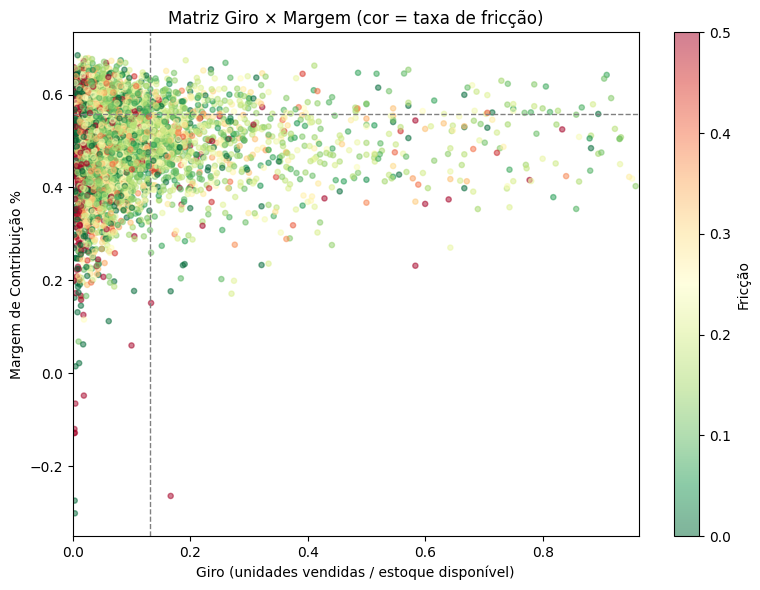

In [71]:

p_giro75 = por_sku_valido['giro'].quantile(0.75)
p_mc75 = por_sku_valido['mc_pct'].quantile(0.75)
p_friccao25 = por_sku_valido['friccao'].quantile(0.25)

sweet_spot_produto = por_sku_valido[
    (por_sku_valido['giro'] >= p_giro75) &
    (por_sku_valido['mc_pct'] >= p_mc75) &
    (por_sku_valido['friccao'] <= p_friccao25)
].sort_values('lucro_liquido_pos_atendimento', ascending=False)

print(f"SKUs no Sweet Spot: {len(sweet_spot_produto)}  |  "
      f"thresholds -> giro≥{p_giro75:.2f}, MC%≥{p_mc75:.1%}, fricção≤{p_friccao25:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(por_sku_valido['giro'], por_sku_valido['mc_pct'],
                 c=por_sku_valido['friccao'], cmap='RdYlGn_r', alpha=0.5, s=14, vmax=por_sku_valido['friccao'].quantile(0.95))
ax.axvline(p_giro75, color='gray', linestyle='--', linewidth=1)
ax.axhline(p_mc75, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Giro (unidades vendidas / estoque disponível)')
ax.set_ylabel('Margem de Contribuição %')
ax.set_title('Matriz Giro × Margem (cor = taxa de fricção)')
plt.colorbar(sc, label='Fricção')
ax.set_xlim(0, por_sku_valido['giro'].quantile(0.97))
plt.tight_layout()
plt.show()


**Entregável obrigatório #2** — Top 10 SKUs no Sweet Spot de Estoque **vs.** 10 SKUs críticos para descontinuação:

In [72]:

top10_sweet_spot = sweet_spot_produto.head(10)[
    ['sku_id', 'nome_produto', 'categoria', 'mc_pct', 'giro', 'friccao', 'lucro_liquido_pos_atendimento']
].reset_index(drop=True)
top10_sweet_spot.insert(0, 'Ranking', ['Sweet Spot'] * len(top10_sweet_spot))

criticos_descontinuacao = por_sku_valido[
    (por_sku_valido['mc_pct'] <= por_sku_valido['mc_pct'].quantile(0.25)) &
    (por_sku_valido['giro'] <= por_sku_valido['giro'].quantile(0.25))
].sort_values('lucro_liquido_pos_atendimento').head(10)[
    ['sku_id', 'nome_produto', 'categoria', 'mc_pct', 'giro', 'friccao', 'lucro_liquido_pos_atendimento']
].reset_index(drop=True)
criticos_descontinuacao.insert(0, 'Ranking', ['Crítico p/ descontinuação'] * len(criticos_descontinuacao))

tabela_sku_comparativa = pd.concat([top10_sweet_spot, criticos_descontinuacao], ignore_index=True)
tabela_sku_comparativa


,Ranking,sku_id,nome_produto,categoria,mc_pct,giro,friccao,lucro_liquido_pos_atendimento
0,Sweet Spot,SKU-00009,Relógio de Parede Básico Preto,Lifestyle,0.57,0.25,0.04,"5,029.47"
1,Sweet Spot,SKU-03245,Carteira Slim Preto,Acessórios,0.58,0.13,0.00,"4,878.71"
2,Sweet Spot,SKU-03942,Sombra Sport Prata,Beleza,0.61,0.13,0.07,"4,658.87"
3,Sweet Spot,SKU-04449,Camisa Social Edição Limitada Prata,Moda,0.62,0.67,0.10,"4,547.83"
4,Sweet Spot,SKU-03394,Calça Jeans Delicado Azul,Moda,0.63,0.13,0.06,"4,437.49"
5,Sweet Spot,SKU-01814,Vela Aromática Delicado Nude,Lifestyle,0.64,0.91,0.07,"4,160.39"
6,Sweet Spot,SKU-00536,Blusa de Tricô Sustentável Prata,Moda,0.59,0.16,0.08,"4,002.28"
7,Sweet Spot,SKU-04116,Sérum Facial Luxo Verde,Beleza,0.58,1.83,0.06,"4,002.03"
8,Sweet Spot,SKU-00859,Camisa Social Delicado Nude,Moda,0.56,0.78,0.08,"4,001.15"
9,Sweet Spot,SKU-00194,Batom Básico Prata,Beleza,0.63,1.06,0.09,"3,509.03"


**"Vilões operacionais"** — margem % acima da mediana, mas onde o custo de atendimento (`custo_operacional_ticket`) consome a maior parte da margem gerada:

In [73]:

por_sku_valido['ratio_custo_tickets_sobre_mc'] = por_sku_valido['custo_tickets'] / por_sku_valido['mc_total'].replace(0, np.nan)
candidatos_viloes = por_sku_valido[por_sku_valido['mc_pct'] >= por_sku_valido['mc_pct'].median()]

viloes_operacionais = candidatos_viloes.sort_values('ratio_custo_tickets_sobre_mc', ascending=False).head(10)[
    ['sku_id', 'nome_produto', 'mc_pct', 'mc_total', 'custo_tickets', 'ratio_custo_tickets_sobre_mc', 'friccao']
].reset_index(drop=True)
viloes_operacionais


,sku_id,nome_produto,mc_pct,mc_total,custo_tickets,ratio_custo_tickets_sobre_mc,friccao
0,SKU-03884,Top Luxo Bege,0.66,164.79,60.00,0.36,2.00
1,SKU-04727,Porta-Retrato Exclusivo Preto,0.54,260.31,90.00,0.35,0.40
2,SKU-01060,Vestido Sport Rosa,0.59,162.44,45.00,0.28,1.50
3,SKU-04145,Top Delicado Branco,0.65,162.96,45.00,0.28,1.00
4,SKU-00499,Almofada Urban Bege,0.59,180.04,47.00,0.26,2.00
5,SKU-04150,Pochete Básico Bege,0.55,249.26,62.00,0.25,1.00
6,SKU-00979,Camisa Social Slim Verde,0.53,284.87,60.00,0.21,0.50
7,SKU-01249,Relógio de Parede Moderno Nude,0.64,324.36,60.00,0.18,1.00
8,SKU-04500,Batom Slim Bege,0.62,184.42,32.00,0.17,0.60
9,SKU-00439,Blusa de Tricô Oversize Bege,0.57,353.33,60.00,0.17,0.67


## 3. Solução 3 — Sweet Spot de Cliente e Aquisição (ICP)

Objetivo: identificar o Perfil de Cliente Ideal — o cluster com melhor relação **LTV Líquido : CAC** e menor consumo de suporte.

$$\text{LTV Efetivo} = \text{LTV Líquido} - \text{CAC} - \sum \text{Custo de Atendimento}$$

In [74]:

# LTV líquido real por cliente (soma da MC de pedidos aprovados)
ltv_liquido = aprovados.groupby('customer_id')['margem_contribuicao'].sum().rename('ltv_liquido_real')

# Canal de aquisição aproximado = canal do primeiro pedido aprovado (proxy, pois não há campo explícito de aquisição)
primeiro_pedido = (aprovados.sort_values('data_pedido')
                   .groupby('customer_id').first()[['canal']]
                   .rename(columns={'canal': 'canal_aquisicao'}))

# Despesa de suporte acumulada por cliente
despesa_suporte = (atendimento.dropna(subset=['customer_id'])
                    .groupby('customer_id')['custo_operacional_ticket'].sum()
                    .rename('despesa_suporte'))

perfil_base = clientes.set_index('customer_id')[['estado', 'segmento_rfm', 'nivel_fidelidade']]
base_cliente = perfil_base.join(ltv_liquido, how='left').join(primeiro_pedido, how='left').join(despesa_suporte, how='left')
base_cliente['ltv_liquido_real'] = base_cliente['ltv_liquido_real'].fillna(0)
base_cliente['despesa_suporte'] = base_cliente['despesa_suporte'].fillna(0)
base_cliente.index.name = 'customer_id'

base_cliente = base_cliente.merge(marketing_canal[['canal', 'cac_medio_ponderado']],
                                   left_on='canal_aquisicao', right_on='canal', how='left').drop(columns=['canal'])
base_cliente.index = perfil_base.index
base_cliente['cac_atribuido'] = base_cliente['cac_medio_ponderado']
base_cliente['ltv_efetivo'] = (base_cliente['ltv_liquido_real']
                                - base_cliente['cac_atribuido'].fillna(0)
                                - base_cliente['despesa_suporte'])

# Base de compradores completa (sem exclusão de contas por volume: base sintética, tratada como está)
compradores = base_cliente[base_cliente['ltv_liquido_real'] != 0].copy()
print(f"Compradores válidos: {len(compradores)} (de {len(base_cliente)} cadastrados em clientes.csv)")


Compradores válidos: 331 (de 15000 cadastrados em clientes.csv)


**Nota sobre o CAC:** os valores de `cac` em `marketing.csv` estão numa escala baixa (mediana ≈ R$ 2,41), muito abaixo do que se espera de um CAC real de e-commerce — provavelmente representam custo por clique/conversão de funil e não o custo plenamente carregado de aquisição de um cliente pagante. Isso infla artificialmente a razão LTV:CAC (todas ficam > 500:1). A leitura de negócio correta aqui é o **ranking relativo entre segmentos**, não a magnitude absoluta da razão.

In [75]:

perfil_segmento = compradores.groupby('segmento_rfm').agg(
    ltv_liquido_medio=('ltv_liquido_real', 'mean'),
    cac_medio=('cac_atribuido', 'mean'),
    despesa_suporte_media=('despesa_suporte', 'mean'),
    ltv_efetivo_medio=('ltv_efetivo', 'mean'),
    n_clientes=('ltv_liquido_real', 'count'),
).reset_index()
perfil_segmento['ratio_ltv_cac'] = perfil_segmento['ltv_liquido_medio'] / perfil_segmento['cac_medio']
perfil_segmento = perfil_segmento.sort_values('ratio_ltv_cac', ascending=False).reset_index(drop=True)
perfil_segmento.round(2)


,segmento_rfm,ltv_liquido_medio,cac_medio,despesa_suporte_media,ltv_efetivo_medio,n_clientes,ratio_ltv_cac
0,Promissor,"43,540.63",1.85,"2,541.35","40,997.43",100,"23,567.97"
1,Em Risco,"31,189.04",1.85,"1,851.47","29,335.72",77,"16,878.26"
2,Campeão,"28,175.14",1.85,"1,623.04","26,550.25",25,"15,238.06"
3,Fiel,"23,278.59",1.85,"1,311.71","21,965.04",58,"12,603.58"
4,Hibernando,"5,876.02",1.84,333.65,"5,540.53",34,"3,187.84"
5,Churn,"1,310.46",1.85,86.32,"1,222.28",37,709.06


Cruzamento adicional por **segmento × canal de aquisição** (célula com pelo menos 5 clientes, para evitar médias de amostra minúscula):

In [76]:

cruzado = compradores.groupby(['segmento_rfm', 'canal_aquisicao']).agg(
    ltv_liquido_medio=('ltv_liquido_real', 'mean'),
    cac_medio=('cac_atribuido', 'mean'),
    despesa_suporte_media=('despesa_suporte', 'mean'),
    n_clientes=('ltv_liquido_real', 'count'),
).reset_index()
cruzado = cruzado[cruzado['n_clientes'] >= 5].copy()
cruzado['ratio_ltv_cac'] = cruzado['ltv_liquido_medio'] / cruzado['cac_medio']
cruzado.sort_values('ratio_ltv_cac', ascending=False).head(10).round(2).reset_index(drop=True)


,segmento_rfm,canal_aquisicao,ltv_liquido_medio,cac_medio,despesa_suporte_media,n_clientes,ratio_ltv_cac
0,Promissor,Instagram Ads,"186,182.72",1.96,"10,798.95",20,"94,812.04"
1,Em Risco,Orgânico,"145,474.23",1.82,"8,807.00",13,"80,060.12"
2,Fiel,Influenciador,"109,835.81",1.76,"6,248.40",5,"62,388.45"
3,Fiel,Instagram Ads,"27,520.95",1.96,"1,484.42",12,"14,014.82"
4,Campeão,Instagram Ads,"27,236.54",1.96,"1,521.83",6,"13,869.99"
5,Em Risco,Instagram Ads,"23,532.88",1.96,"1,315.23",13,"11,983.93"
6,Fiel,Email Marketing,"16,225.49",1.79,852.29,7,"9,048.57"
7,Fiel,Marketplace,"15,491.96",1.83,922.88,16,"8,481.25"
8,Promissor,Influenciador,"13,950.64",1.76,772.30,10,"7,924.18"
9,Campeão,Marketplace,"13,741.40",1.83,805.00,7,"7,522.89"


**Entregável obrigatório #3** — Perfil do segmento de clientes (ICP) com melhor indicador unitário (maior LTV Efetivo — já líquido de CAC e custo de suporte — entre os segmentos com razão LTV:CAC ≥ 3:1):

In [77]:

icp_elegivel = perfil_segmento[perfil_segmento['ratio_ltv_cac'] >= 3].sort_values('ltv_efetivo_medio', ascending=False)
melhor_icp = icp_elegivel.iloc[0]

print("=== Perfil de Cliente Ideal (ICP) recomendado ===")
print(f"Segmento RFM        : {melhor_icp['segmento_rfm']}")
print(f"LTV líquido médio    : R$ {melhor_icp['ltv_liquido_medio']:,.2f}")
print(f"CAC médio atribuído  : R$ {melhor_icp['cac_medio']:,.2f}")
print(f"Razão LTV:CAC        : {melhor_icp['ratio_ltv_cac']:.1f} : 1")
print(f"Despesa média suporte: R$ {melhor_icp['despesa_suporte_media']:,.2f}")
print(f"LTV efetivo médio    : R$ {melhor_icp['ltv_efetivo_medio']:,.2f}")
print(f"Base de clientes     : {int(melhor_icp['n_clientes'])} clientes")

melhor_canal_desse_segmento = cruzado[cruzado['segmento_rfm'] == melhor_icp['segmento_rfm']].sort_values('ratio_ltv_cac', ascending=False)
print(f"\nMelhor(es) canal(is) de aquisição para esse segmento:")
melhor_canal_desse_segmento[['canal_aquisicao', 'ltv_liquido_medio', 'cac_medio', 'ratio_ltv_cac', 'n_clientes']]


=== Perfil de Cliente Ideal (ICP) recomendado ===
Segmento RFM        : Promissor
LTV líquido médio    : R$ 43,540.63
CAC médio atribuído  : R$ 1.85
Razão LTV:CAC        : 23568.0 : 1
Despesa média suporte: R$ 2,541.35
LTV efetivo médio    : R$ 40,997.43
Base de clientes     : 100 clientes

Melhor(es) canal(is) de aquisição para esse segmento:


,canal_aquisicao,ltv_liquido_medio,cac_medio,ratio_ltv_cac,n_clientes
37,Instagram Ads,"186,182.71",1.96,"94,812.04",20
36,Influenciador,"13,950.64",1.76,"7,924.18",10
39,Orgânico,"11,238.27",1.82,"6,184.86",10
35,Google Ads,"10,742.84",1.88,"5,728.94",22
38,Marketplace,"5,813.73",1.83,"3,182.80",18
40,TikTok Ads,"3,055.15",1.75,"1,745.66",7
34,Email Marketing,"1,241.83",1.79,692.54,13


In [78]:

from IPython.display import Markdown, display

estados_caros_str = ", ".join(top5_frete_caro['estado'].tolist())
economia_frete = custo_frete_top5 * 0.20
pct_ganho = ganho_total / mc_atual * 100

resumo_md = f"""## Sumário Executivo — Ações Recomendadas e Entregáveis

**Ações prontas para produção (Solução 1, Seção 1.2):**
1. Ativar o motor de regras `avaliar_checkout` no fluxo de checkout — bloqueia desconto espontâneo para clientes de alto valor no canal Orgânico e aplica piso de margem de 10%. Ganho retroativo medido: **R$ {ganho_total:,.2f}** no período da base (+{pct_ganho:.2f}% de margem, mesmo volume de pedidos).
2. Manter a regra de Ticket_min por estado como guard-rail (não se aciona hoje, mas protege contra pedidos de ticket muito baixo no futuro).
3. Levar os estados com maior custo médio de frete ({estados_caros_str}) para negociação com transportadora — economia potencial estimada de R$ {economia_frete:,.2f} com uma redução de 20% no custo.

**Entregáveis obrigatórios do prompt:**
1. **Auditoria de perdas + matriz de thresholds por estado** → Seção 1.1 (`auditoria`, `tabela_thresholds`) e backtest do motor de regras → Seção 1.2 (`backtest_regras`).
2. **Top 10 SKUs Sweet Spot vs. 10 críticos para descontinuação** → Seção 2.2 (`tabela_sku_comparativa`), com "vilões operacionais" em `viloes_operacionais`.
3. **Perfil do segmento com melhor LTV:CAC (ICP)** → Seção 3 (`melhor_icp`).
4. **Demonstração do motor de decisão com 3 perfis de pedidos simulados** → Seção 1.2 (`resumo_demo`), com o simulador baseado em ML como comparação complementar na Seção 1.4.

**Achados que merecem validação com dados reais antes de escalar:**
- O modelo de aprovação de pagamento não encontrou sinal preditivo (AUC ≈ 0,50) — por isso a ação recomendada é o motor de regras determinístico (Seção 1.2), não o simulador baseado em ML (Seção 1.4), que fica pronto para re-treinar quando houver sinal real de conversão.
- A escala do `cac` em `marketing.csv` parece subdimensionada frente ao LTV observado; recomenda-se validar a definição/unidade dessa métrica antes de usar a razão LTV:CAC absoluta em decisões de investimento de mídia (o ranking relativo entre segmentos continua válido).
"""
display(Markdown(resumo_md))


## Sumário Executivo — Ações Recomendadas e Entregáveis

**Ações prontas para produção (Solução 1, Seção 1.2):**
1. Ativar o motor de regras `avaliar_checkout` no fluxo de checkout — bloqueia desconto espontâneo para clientes de alto valor no canal Orgânico e aplica piso de margem de 10%. Ganho retroativo medido: **R$ 43,051.38** no período da base (+0.48% de margem, mesmo volume de pedidos).
2. Manter a regra de Ticket_min por estado como guard-rail (não se aciona hoje, mas protege contra pedidos de ticket muito baixo no futuro).
3. Levar os estados com maior custo médio de frete (MS, AC, SC, PA, AM) para negociação com transportadora — economia potencial estimada de R$ 2,869.62 com uma redução de 20% no custo.

**Entregáveis obrigatórios do prompt:**
1. **Auditoria de perdas + matriz de thresholds por estado** → Seção 1.1 (`auditoria`, `tabela_thresholds`) e backtest do motor de regras → Seção 1.2 (`backtest_regras`).
2. **Top 10 SKUs Sweet Spot vs. 10 críticos para descontinuação** → Seção 2.2 (`tabela_sku_comparativa`), com "vilões operacionais" em `viloes_operacionais`.
3. **Perfil do segmento com melhor LTV:CAC (ICP)** → Seção 3 (`melhor_icp`).
4. **Demonstração do motor de decisão com 3 perfis de pedidos simulados** → Seção 1.2 (`resumo_demo`), com o simulador baseado em ML como comparação complementar na Seção 1.4.

**Achados que merecem validação com dados reais antes de escalar:**
- O modelo de aprovação de pagamento não encontrou sinal preditivo (AUC ≈ 0,50) — por isso a ação recomendada é o motor de regras determinístico (Seção 1.2), não o simulador baseado em ML (Seção 1.4), que fica pronto para re-treinar quando houver sinal real de conversão.
- A escala do `cac` em `marketing.csv` parece subdimensionada frente ao LTV observado; recomenda-se validar a definição/unidade dessa métrica antes de usar a razão LTV:CAC absoluta em decisões de investimento de mídia (o ranking relativo entre segmentos continua válido).
